<a href="https://colab.research.google.com/github/nidhita2/Deep-Learning/blob/LE-NET--5/LE_NET_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
#LE NET -5 CNN FOR MNIST CLASSIFICATION
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, AveragePooling2D

In [17]:
# load the mnist dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("training data", x_train.shape)
print("testing data", x_test.shape)

training data (60000, 28, 28)
testing data (10000, 28, 28)


In [18]:
#normalize the image
x_train = x_train / 255.0
x_test = x_test / 255.0

In [12]:
#adding the channel dimension
x_train =x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)
#after reshaping
print("training data", x_train.shape)
print("testing data", x_test.shape )

training data (60000, 28, 28, 1)
testing data (10000, 28, 28, 1)


In [19]:
#creating LE NET-5 CNN
model=Sequential([
    #c1 convolution layer 1
    layers.Conv2D(filters=6, kernel_size=(5,5), activation='tanh', input_shape=(28,28,1) ),
    #P1 pooling layer
    layers.AveragePooling2D(pool_size=(2,2), strides=2),
    # C2 convolutional layer 2
    layers.Conv2D(filters=16, kernel_size=(5,5), activation='tanh'),
    #P2 pooling layer
    layers.AveragePooling2D(pool_size=(2,2), strides=2),
    #flattern
    layers.Flatten(),
    #fully connected layer
    layers.Dense(units=120, activation='tanh'),
    layers.Dense(units=84, activation='tanh'),
    #output layer
    layers.Dense(units=10, activation='softmax')
    ])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [22]:
#training the model
history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.8903 - loss: 0.3817 - val_accuracy: 0.9577 - val_loss: 0.1518
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9592 - loss: 0.1348 - val_accuracy: 0.9748 - val_loss: 0.0951
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.9728 - loss: 0.0879 - val_accuracy: 0.9805 - val_loss: 0.0705
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9800 - loss: 0.0658 - val_accuracy: 0.9798 - val_loss: 0.0673
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accuracy: 0.9843 - loss: 0.0523 - val_accuracy: 0.9837 - val_loss: 0.0566
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.9864 - loss: 0.0449 - val_accuracy: 0.9828 - val_loss: 0.0559
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.9886 - loss: 0.0367 - val_accuracy: 0.9838 - val_loss: 0.0564
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9901 - loss: 0.0321 - 

In [24]:
#test the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9859 - loss: 0.0441
Test accuracy: 0.9858999848365784


In [26]:
# making predictions
predictions= model.predict(x_test)
print("predicted digit:",predictions[0].argmax)
print("actual digit:",y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
predicted digit: <built-in method argmax of numpy.ndarray object at 0x7e71bf88aa90>
actual digit: 7


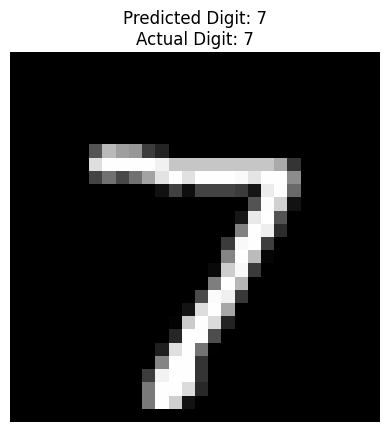

In [27]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(
    f"Predicted Digit: {predictions[0].argmax()}\n"
    f"Actual Digit: {y_test[0]}"
)
plt.axis('off')
plt.show()